# Indiana Pines

1. Import dependencies

In [ ]:
import random
import torch
import multiprocessing
import time
import numpy as np

import torch.utils.data as data

from src.util.torch import resolve_torch_device
from src.util.hsi import (
    extract_patches,
    reduce_hsi_dim,
    preprocess_hsi,
    PreProcessType,
    DimReductionType,
)
from src.data.indian_pines import load_indian_pines
from src.visualization.plot import (
    plot_epoch_generic,
)

from src.util.reporting import (
    create_model_name,
    report_run,
    read_report_to_show,
)
from src.util.list_ext import smooth_moving_average
from src.model.dbda import DBDA
from src.trainer.masked_autoencoder_trainer import (
    MaskedAutoEncoderTrainer,
)
from src.util.loss import MaskedAutoencoderLoss
from src.util.torch import save_model
from src.trainer.base_trainer import AdamOptimizedModule
from src.model.autoencoder import AutoEncoder
from src.model.vit_hsi_decoder import ViTHsiDecoder
from src.util.masking import HsiPatchMasking
from src.data.dataset_decorator import RandomFlipDatasetDecorator
from src.trainer.base_trainer import LrSchedulerProvider

2. Prepare env

In [2]:
run_desk = "Lower LR + More epochs"

In [3]:
learning_rate = 5e-4
weight_decay = 0
num_epochs = 120

In [4]:
loss_alpha = 1
loss_beta = 0.1

mask_ratio = 0.75
mask_mode = "spatial"
fil_value = "noise"

latent_space_size = 256
decoder_layers = 8
decoder_embed_dim = 256
decoder_heads = 16
decoder_mlp_dim = 512
latent_space_size = 256

In [5]:
batch_size = 512
patch_size = 9
target_dim = 75

examples_per_class = {}

pre_process_type = PreProcessType.STANDARTIZATION
dim_reduction_type = DimReductionType.PCA

In [6]:
random_seed = 42

random.seed(random_seed)
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = resolve_torch_device()

In [7]:
epoch_seconds = int(time.time())

In [8]:
torch.cuda.empty_cache()

In [9]:
torch.set_float32_matmul_precision("medium")

In [10]:
f"Device is {device}"

'Device is cuda'

3. Load dataset

In [11]:
image, labels = load_indian_pines()

image_h, image_w, image_c = image.shape

In [12]:
_, image = preprocess_hsi(image, pre_process_type)

In [13]:
_, target_dim, image = reduce_hsi_dim(
    image, target_dim, dim_reduction_type, random_seed
)

In [14]:
x, y = extract_patches(image, labels, patch_size=patch_size)

In [15]:
num_classes = len(np.unique(y))

f"Number of classes {num_classes}"

'Number of classes 17'

In [16]:
x_tensor = torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2) 
y_tensor = torch.tensor(y, dtype=torch.long)

In [17]:
cpu_count = multiprocessing.cpu_count()

f"Setting num_workers to {cpu_count}"

'Setting num_workers to 24'

In [18]:
full_dataset = data.TensorDataset(x_tensor, y_tensor)

full_loader = data.DataLoader(
    RandomFlipDatasetDecorator(full_dataset),
    batch_size=batch_size,
    shuffle=False,
    num_workers=cpu_count,
    persistent_workers=True,
)

4. Train model

In [19]:
encoder = DBDA(
    band=target_dim,
    classes=latent_space_size,
)

In [20]:
decoder = ViTHsiDecoder(
    latent_dim=latent_space_size,
    out_h=patch_size,
    out_w=patch_size,
    out_bands=target_dim,
    embed_dim=decoder_embed_dim,
    n_layers=decoder_layers,
    n_heads=decoder_heads,
    mlp_dim=decoder_mlp_dim,
)

In [ ]:
model = AdamOptimizedModule(
    net=AutoEncoder(encoder, decoder),
    lr=learning_rate,
    weight_decay=weight_decay,
    scheduler=LrSchedulerProvider(
        t_initial=num_epochs,
        lr_min=learning_rate * 0.01,
        warmup_t=int(np.ceil(0.1 * num_epochs)),
        warmup_lr_init=learning_rate * 0.01,
    ),
)

In [22]:
trainer = MaskedAutoEncoderTrainer(
    loss_fun=MaskedAutoencoderLoss(alpha=loss_alpha, beta=loss_beta),
    epochs=num_epochs,
    masking=HsiPatchMasking(
        mask_ratio=mask_ratio, mode=mask_mode, fill_value=fil_value
    ),
    device=device,
)

In [23]:
feedback = trainer.fit(model, full_loader)

  0%|          | 0/120 [00:00<?, ?it/s]

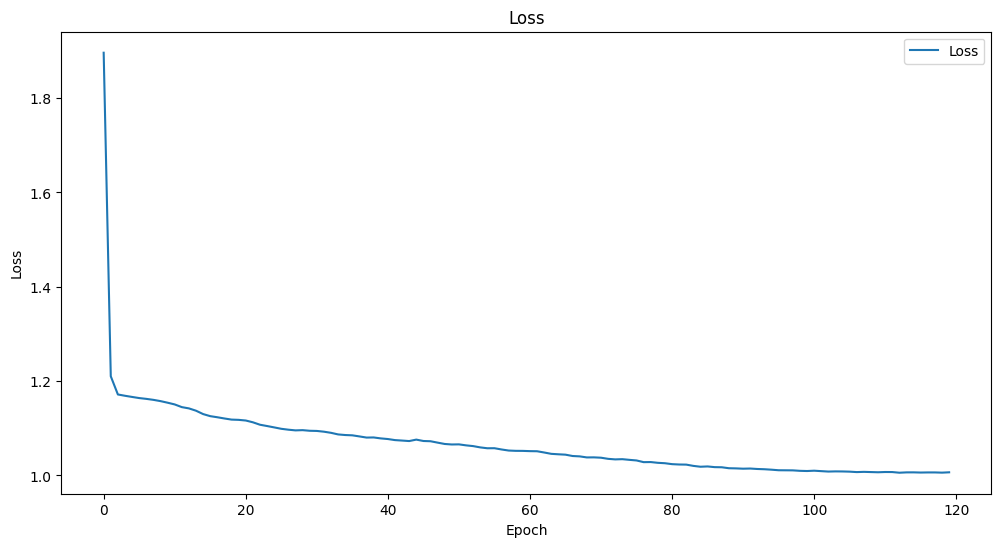

In [24]:
smothed_train = smooth_moving_average([it.train["train_loss"] for it in feedback.history], 1)

plot_epoch_generic(smothed_train, desc="Loss")

In [25]:
validation_result = trainer.validate(model, full_loader)

validation_result

{'eval_loss': 1.0212685948326474}

5. Save weights

In [26]:
saved_model_name = f"indian_pines_mae_encoder_{run_desk.replace(" ", "_").lower()}"

save_model(encoder, saved_model_name)

PosixPath('/home/melal/Workspace/hsi-classification-playground/models/indian_pines_mae_encoder_lower_lr_+_more_epochs.pth')

6. Write report

In [27]:
model_name = create_model_name("indian_pines_mae", {})

model_category = "dbda"

In [28]:
run_params = {
    "num_epochs": num_epochs,
    "batch_size": batch_size,
    "patch_size": patch_size,
    "target_dim": target_dim,
    "loss_alpha": loss_alpha,
    "loss_beta": loss_beta,
    "mask_ratio": mask_ratio,
    "mask_mode": mask_mode,
    "fil_value": fil_value,
    "embedding_size": latent_space_size,
    "pre_process_type": str(pre_process_type),
    "dim_reduction_type": str(dim_reduction_type),
    "saved_model_name": saved_model_name,
    "decoder_layers": decoder_layers,
    "decoder_embed_dim": decoder_embed_dim,
    "decoder_heads": decoder_heads,
    "decoder_mlp_dim": decoder_mlp_dim,
}

report_run(
    model_name=model_name,
    model_category=model_category,
    run_desc=run_desk,
    run_params=run_params | model.get_params(),
    run_metrics={"loss": validation_result["eval_loss"]},
)

PosixPath('/home/melal/Workspace/hsi-classification-playground/reports/runs/indian_pines_mae_.csv')

In [29]:
read_report_to_show(model_name, sort_by_metric="loss", ascending=True)

,timestamp,model_category,run_desc,params,loss
13,2025-08-20T23:26:16.973508+00:00,dbda,Lower LR + More epochs,"{""num_epochs"": 120, ""batch_size"": 512, ""patch_...",1.021269
12,2025-08-20T22:50:51.091310+00:00,dbda,Lower LR,"{""num_epochs"": 60, ""batch_size"": 512, ""patch_s...",1.061537
2,2025-08-12T11:09:03.655035+00:00,dbda,Default run ( indian_pines_mae_encoder_1754996...,"{""num_epochs"": 40, ""batch_size"": 64, ""patch_si...",1.084825
1,2025-08-12T09:53:39.716280+00:00,dbda,Fill with 0 ( indian_pines_mae_encoder_1754991...,"{""num_epochs"": 40, ""batch_size"": 64, ""patch_si...",1.100103
5,2025-08-20T20:55:03.655898+00:00,dbda,Copy masking from MAE PU,"{""num_epochs"": 40, ""batch_size"": 64, ""patch_si...",1.100758
10,2025-08-20T22:12:13.381574+00:00,dbda,Copy masking from MAE PU + More epochs + Flips...,"{""num_epochs"": 60, ""batch_size"": 512, ""patch_s...",1.103324
11,2025-08-20T22:28:21.306329+00:00,dbda,Copy masking from MAE PU + More epochs + Flips...,"{""num_epochs"": 60, ""batch_size"": 512, ""patch_s...",1.103330
9,2025-08-20T21:58:34.032444+00:00,dbda,Copy masking from MAE PU + More epochs + Flips,"{""num_epochs"": 60, ""batch_size"": 64, ""patch_si...",1.104983
0,2025-08-12T09:22:58.260734+00:00,dbda,Default run,"{""num_epochs"": 40, ""batch_size"": 64, ""patch_si...",1.105212
7,2025-08-20T21:24:44.715560+00:00,dbda,Copy masking from MAE PU + Remove scheduler + ...,"{""num_epochs"": 60, ""batch_size"": 64, ""patch_si...",1.122146


In [30]:
read_report_to_show(
    model_name, sort_by_metric="loss", model_category=model_category, ascending=True
)

,timestamp,run_desc,params,loss
13,2025-08-20T23:26:16.973508+00:00,Lower LR + More epochs,"{""num_epochs"": 120, ""batch_size"": 512, ""patch_...",1.021269
12,2025-08-20T22:50:51.091310+00:00,Lower LR,"{""num_epochs"": 60, ""batch_size"": 512, ""patch_s...",1.061537
2,2025-08-12T11:09:03.655035+00:00,Default run ( indian_pines_mae_encoder_1754996...,"{""num_epochs"": 40, ""batch_size"": 64, ""patch_si...",1.084825
1,2025-08-12T09:53:39.716280+00:00,Fill with 0 ( indian_pines_mae_encoder_1754991...,"{""num_epochs"": 40, ""batch_size"": 64, ""patch_si...",1.100103
5,2025-08-20T20:55:03.655898+00:00,Copy masking from MAE PU,"{""num_epochs"": 40, ""batch_size"": 64, ""patch_si...",1.100758
10,2025-08-20T22:12:13.381574+00:00,Copy masking from MAE PU + More epochs + Flips...,"{""num_epochs"": 60, ""batch_size"": 512, ""patch_s...",1.103324
11,2025-08-20T22:28:21.306329+00:00,Copy masking from MAE PU + More epochs + Flips...,"{""num_epochs"": 60, ""batch_size"": 512, ""patch_s...",1.103330
9,2025-08-20T21:58:34.032444+00:00,Copy masking from MAE PU + More epochs + Flips,"{""num_epochs"": 60, ""batch_size"": 64, ""patch_si...",1.104983
0,2025-08-12T09:22:58.260734+00:00,Default run,"{""num_epochs"": 40, ""batch_size"": 64, ""patch_si...",1.105212
7,2025-08-20T21:24:44.715560+00:00,Copy masking from MAE PU + Remove scheduler + ...,"{""num_epochs"": 60, ""batch_size"": 64, ""patch_si...",1.122146
